<a href="https://colab.research.google.com/github/nurcoz/Udemy_time_series/blob/main/Introduction_to_Time_Series_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup

In [1]:
# Mount the drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd /content/drive/MyDrive/Python - Time Series Forecasting/Time Series Analysis/Introduction to Time Series Forecasting

/content/drive/MyDrive/Python - Time Series Forecasting/Time Series Analysis/Introduction to Time Series Forecasting


In [3]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
# Load the dataset
df = pd.read_csv('bitcoin_price.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


## Time Series Index

In [5]:
# Convert "Date" variable to a datetime object with the right format YYYY-MM-DD or "%Y-%m-%d"
# Kafa karışıklığı olmaması için önemli bir adım
df["Date"] = pd.to_datetime(df["Date"], format = "%Y-%m-%d")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [6]:
# Set Date as index
# Kolon olarak da eklememiz lazım- bunu indexle yapıyoruz
df.set_index("Date", inplace=True)
# Aşağıda tabloda görüldüğü gibi zaman serisi olarak aldık Date değişkenini
df.head()


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [7]:
# Veri setinde spesifik bir tarih seçmek için (index üzerinden gitmek için)
# Aşağıda görüldüğü gibi belirli bir satır için tüm değerleri aldı
df.loc['2021-11-09']

,2021-11-09
Open,6.754973e+04
High,6.853034e+04
Low,6.638206e+04
Close,6.697183e+04
Adj Close,6.697183e+04
Volume,4.235799e+10


In [8]:
# Set the index when we import the data
# Index sütununu tarihe eşitliyoruz
# Verileri içe aktarırken indeksi ayarlayabiliriz.
df1 = pd.read_csv("bitcoin_price.csv", index_col= "Date", parse_dates=True)
df1.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [9]:
# Resample data to a different time granularity
# Haftalık resample ediyoruz bu yüzden W dedik
df.resample('W').mean()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-21,429.916998,437.718195,406.624402,416.859003,416.859003,3.138068e+07
2014-09-28,410.650718,418.668993,399.377141,407.692566,407.692566,2.668180e+07
2014-10-05,369.774288,376.721000,353.207140,361.426570,361.426570,3.952256e+07
2014-10-12,346.927429,363.308864,337.567858,355.234580,355.234580,4.873611e+07
2014-10-19,389.010284,397.790427,380.410575,390.479854,390.479854,2.241458e+07
...,...,...,...,...,...,...
2023-12-03,38038.414062,38743.479353,37766.444196,38399.994978,38399.994978,1.919430e+10
2023-12-10,43002.227121,44027.167411,42586.383929,43538.877232,43538.877232,2.692909e+10
2023-12-17,42369.368862,42969.940848,41148.103237,42020.472656,42020.472656,2.407050e+10


## Exploratory Data Analysis

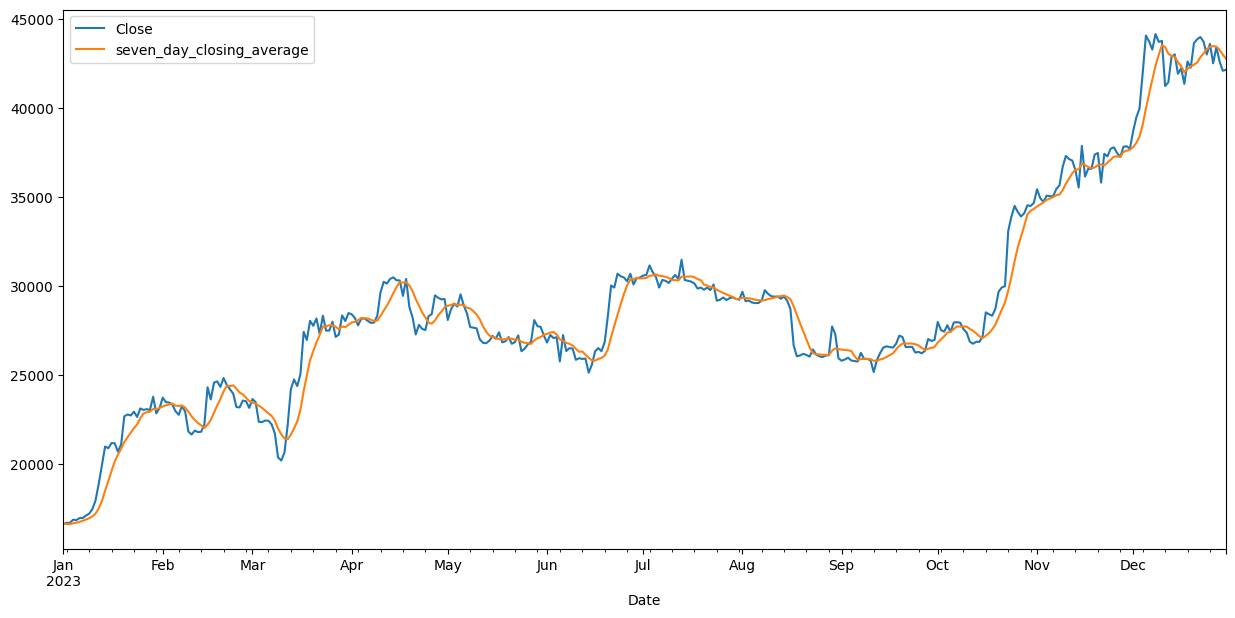

In [10]:
# Generate 7 day rolling average for closing price
df['seven_day_closing_average'] = df['Close'].rolling(7).mean()
df[['Close', 'seven_day_closing_average']].loc['2023'].plot(figsize=(15,7))
plt.show()

In [11]:
# Find the month with a highest closing average
df.resample('ME').max()['Close'].idxmax()

Timestamp('2021-11-30 00:00:00')

In [12]:
# Preview the last 5 rows of the dataset
df.tail()

,Open,High,Low,Close,Adj Close,Volume,seven_day_closing_average
Date,,,,,,,
2023-12-26,43599.847656,43603.175781,41676.488281,42520.402344,42520.402344,30026850982,43486.929688
2023-12-27,42518.468750,43683.160156,42167.582031,43442.855469,43442.855469,25260941032,43457.016183
2023-12-28,43468.199219,43804.781250,42318.550781,42627.855469,42627.855469,22992093014,43279.688058
2023-12-29,42614.644531,43124.324219,41424.062500,42099.402344,42099.402344,26000021055,43008.473772
2023-12-30,42091.753906,42584.125000,41556.226562,42156.902344,42156.902344,16013925945,42782.382254


In [13]:
# Compute the percentage change for the close variable
df['daily_returns_100%'] = df['Close'].pct_change() * 100

In [14]:
# Let's check which days had more then 10% change in price (hem -10 hem 10 dan büyük mü bakmak için mutlak değerini aldık)
df[abs(df['daily_returns_100%']) > 10 ]

,Open,High,Low,Close,Adj Close,Volume,seven_day_closing_average,daily_returns_100%
Date,,,,,,,,
2014-11-12,367.984985,429.717987,367.984985,423.561005,423.561005,45783200,365.519579,15.193570
2015-01-03,314.846008,315.149994,281.082001,281.082001,281.082001,33054400,310.171718,-10.776686
2015-01-13,267.394012,268.277008,219.906006,225.860992,225.860992,72843904,271.743853,-15.659308
2015-01-14,223.893997,223.893997,171.509995,178.102997,178.102997,97638704,255.138994,-21.144862
2015-01-15,176.897003,229.067001,176.897003,209.843994,209.843994,81773504,244.638280,17.821709
...,...,...,...,...,...,...,...,...
2022-09-09,19328.140625,21439.410156,19310.962891,21381.152344,21381.152344,48469528171,19781.450056,10.612188
2022-11-08,20600.671875,20664.607422,17603.544922,18541.271484,18541.271484,118992465607,20409.998326,-10.006132
2022-11-09,18543.761719,18590.458984,15682.692383,15880.780273,15880.780273,102905151606,19798.752093,-14.349022


## Data Visualization

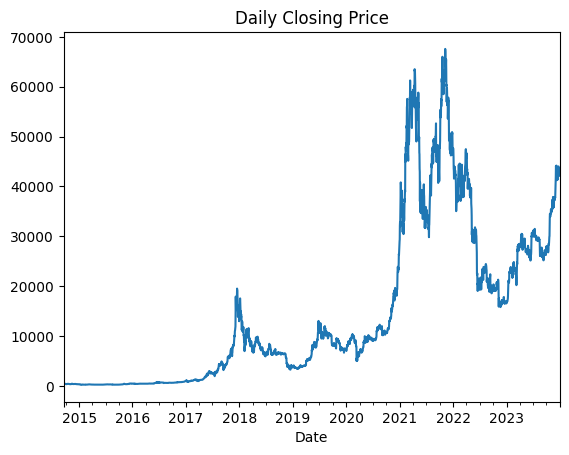

In [15]:
# Daily closing price plot
df["Close"].plot(title = "Daily Closing Price")
plt.show()

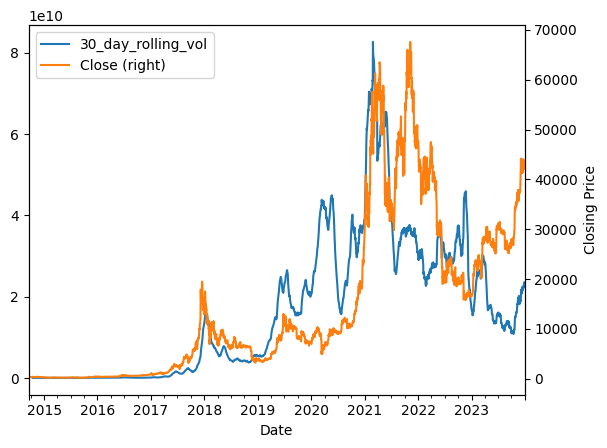

In [16]:
# Create a new variable for the 30 days rolling average
df['30_day_rolling_vol'] = df['Volume'].rolling(30).mean()

# Plot the closing price and the 30 day rolling volume
df[['30_day_rolling_vol']].plot(legend = True)
ax = df["Close"].plot(secondary_y = True, legend = True)
ax.set_ylabel("Closing Price")
plt.show()

In [17]:
# Perform correlation between closing price and 30 day rolling average
print(df['30_day_rolling_vol'].corr(df['Close']))
df[['Close', '30_day_rolling_vol']].corr()

0.750445379618605


,Close,30_day_rolling_vol
Close,1.000000,0.750445
30_day_rolling_vol,0.750445,1.000000


This is Pearson Correlation which often is not ideal for time series. You might want to check out Spearmen Correlation.

If we use Pearson, it's still %90 correct

## Data Manipulation

In [18]:
# Clear missing values
df.isnull().sum()

,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0
seven_day_closing_average,6
daily_returns_100%,1
30_day_rolling_vol,29


In [19]:
# Now we are going to fill these missing values with the next observation
# Day 29 -> missing
# Day 30 we have a value
# Day 29 has now value of day 30
# df["30_day_rolling_vol"].fillna(method = "bfill", inplace = True) # depricated version
df['30_day_rolling_vol'] = df["30_day_rolling_vol"].bfill() # bfill metodu ile 29. günü doldurmak için 30. günü alırız , ffill'de 29. günü doldurmak için 28. günü alırız

In [20]:
# Interpolate values
df['seven_day_closing_average'] = df['seven_day_closing_average'].interpolate(method = "linear")

In [21]:
# Fetch the index
df.index.dayofweek

Index([2, 3, 4, 5, 6, 0, 1, 2, 3, 4,
       ...
       3, 4, 5, 6, 0, 1, 2, 3, 4, 5],
      dtype='int32', name='Date', length=3392)

In [22]:
# Extract time variables
df['year'] = df.index.year
df['month'] = df.index.month
df['day'] = df.index.day
df['day_of_week'] = df.index.dayofweek
df['weekday'] = df.index.day_name()
df['weekday_numeric'] = df.index.weekday

# Set a variable for the weekend
# Binary olması için, default boolean değerini datatype int yaptık
df['is_weekend'] = df['weekday_numeric'].isin([5,6]).astype(int)
df.head()

,Open,High,Low,Close,Adj Close,Volume,seven_day_closing_average,daily_returns_100%,30_day_rolling_vol,year,month,day,day_of_week,weekday,weekday_numeric,is_weekend
Date,,,,,,,,,,,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800,NaN,NaN,3.624856e+07,2014,9,17,2,Wednesday,2,0
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200,NaN,-7.192558,3.624856e+07,2014,9,18,3,Thursday,3,0
2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700,NaN,-6.984265,3.624856e+07,2014,9,19,4,Friday,4,0
2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600,NaN,3.573492,3.624856e+07,2014,9,20,5,Saturday,5,1
2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100,NaN,-2.465854,3.624856e+07,2014,9,21,6,Sunday,6,1


In [23]:
# Feature Engineering - Lagged Variables
df['lag_1'] =  df['Close'].shift(1)
df['lag_2'] =  df['Close'].shift(2)
df.head()

,Open,High,Low,Close,Adj Close,Volume,seven_day_closing_average,daily_returns_100%,30_day_rolling_vol,year,month,day,day_of_week,weekday,weekday_numeric,is_weekend,lag_1,lag_2
Date,,,,,,,,,,,,,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800,NaN,NaN,3.624856e+07,2014,9,17,2,Wednesday,2,0,NaN,NaN
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200,NaN,-7.192558,3.624856e+07,2014,9,18,3,Thursday,3,0,457.334015,NaN
2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700,NaN,-6.984265,3.624856e+07,2014,9,19,4,Friday,4,0,424.440002,457.334015
2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600,NaN,3.573492,3.624856e+07,2014,9,20,5,Saturday,5,1,394.795990,424.440002
2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100,NaN,-2.465854,3.624856e+07,2014,9,21,6,Sunday,6,1,408.903992,394.795990
